In [55]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/Mall_Customers.csv


In [56]:
import pandas as pd
df=pd.read_csv('/kaggle/input/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/Mall_Customers.csv')

In [57]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [59]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [60]:
from sklearn.cluster import KMeans

In [61]:
from sklearn.cluster import KMeans

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

wcss = []

for i in range(1,11):

    kmeans = KMeans(n_clusters=i, random_state=42)

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

Plotting the Elbow Graph

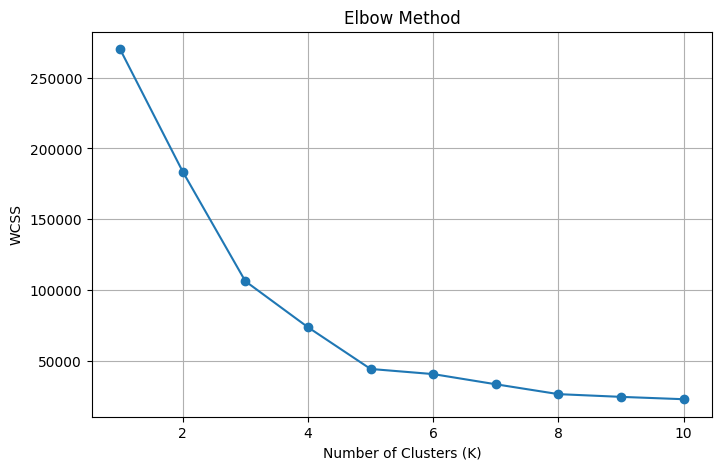

In [62]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.grid(True)

plt.show()

In [63]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5, random_state=42)

clusters = kmeans.fit_predict(X)

In [64]:
df['Cluster'] = clusters

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


Visualize customer segments 

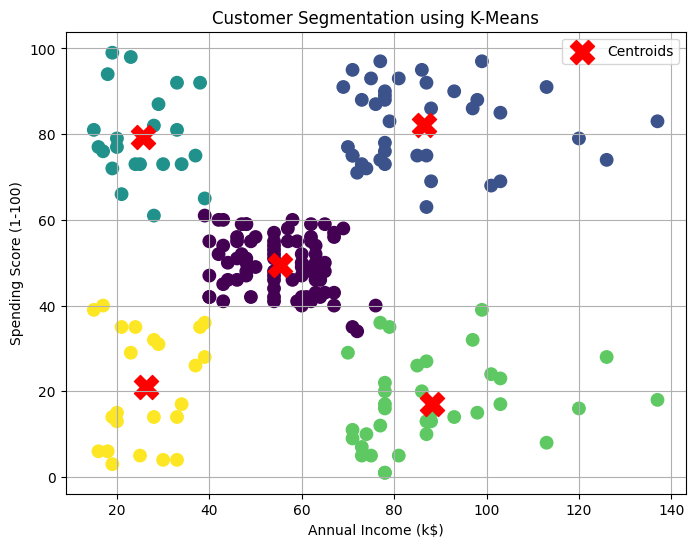

In [65]:
plt.figure(figsize=(8,6))

plt.scatter(
    X.iloc[:,0],
    X.iloc[:,1],
    c=clusters,
    cmap='viridis',
    s=80
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300,
    c='red',
    marker='X',
    label='Centroids'
)

plt.title("Customer Segmentation using K-Means")

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")

plt.legend()

plt.grid(True)

plt.show()

Silhouette Score.

In [66]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X, clusters)

print("Silhouette Score:", score)

Silhouette Score: 0.553931997444648


Cluster-wise Customer Analysis

In [67]:
cluster_summary = df.groupby('Cluster').agg({
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean',
    'Age': 'mean',
    'CustomerID': 'count'
})

cluster_summary.rename(columns={'CustomerID':'Number of Customers'}, inplace=True)

cluster_summary

,Annual Income (k$),Spending Score (1-100),Age,Number of Customers
Cluster,,,,
0,55.296296,49.518519,42.716049,81
1,86.538462,82.128205,32.692308,39
2,25.727273,79.363636,25.272727,22
3,88.200000,17.114286,41.114286,35
4,26.304348,20.913043,45.217391,23


In [68]:
cluster_names = {
    0: "Regular Customers",
    1: "High Income - high Spending",
    2: "low income- high spending",
    3: "high income- low spending",
    4: "Low Income - low Spending"
}

df["Customer Segment"] = df["Cluster"].map(cluster_names)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Customer Segment
0,1,Male,19,15,39,4,Low Income - low Spending
1,2,Male,21,15,81,2,low income- high spending
2,3,Female,20,16,6,4,Low Income - low Spending
3,4,Female,23,16,77,2,low income- high spending
4,5,Female,31,17,40,4,Low Income - low Spending


counting customers in each cluster

In [69]:
df["Customer Segment"].value_counts()

Customer Segment
Regular Customers              81
High Income - high Spending    39
high income- low spending      35
Low Income - low Spending      23
low income- high spending      22
Name: count, dtype: int64

## Business Insights

### VIP Customers
- Offer premium memberships.
- Provide exclusive rewards.

### High Income - Low Spending
- Target with discount coupons and loyalty programs.

### Budget Customers
- Promote affordable products.

### Low Income - High Spending
- Recommend budget-friendly combo offers.

### Regular Customers
- Maintain engagement with seasonal offers.

## Conclusion

This project applied the K-Means clustering algorithm to segment retail customers based on Annual Income and Spending Score.

The Elbow Method suggested using **5 clusters**, which successfully grouped customers into meaningful segments such as VIP customers, regular customers, potential customers, and budget shoppers.

Customer segmentation helps businesses create targeted marketing strategies, improve customer satisfaction, and increase sales through personalized offers.